In [1]:
from glob import glob
import shutil 
import os
import dicom2nifti
import nibabel as nib
import numpy as np
import torch

In [2]:
from monai.transforms import (
    Compose,
    EnsureChannelFirstd,
    LoadImaged,
    Resized,
    ToTensord,
    Spacingd,
    Orientationd,
    ScaleIntensityRanged,
    CropForegroundd,

)

# from monai.transforms import (
#     Activations,
#     Activationsd,
#     AsDiscrete,
#     AsDiscreted,
#     Compose,
#     Invertd,
#     LoadImaged,
#     MapTransform,
#     NormalizeIntensityd,
#     Orientationd,
#     RandFlipd,
#     RandScaleIntensityd,
#     RandShiftIntensityd,
#     RandSpatialCropd,
#     Spacingd,
#     EnsureTyped,
#     EnsureChannelFirstd,
# )

In [3]:
from monai.data import DataLoader, Dataset, CacheDataset
from monai.utils import set_determinism
from monai.utils import first
import matplotlib.pyplot as plt
from tqdm import tqdm

In [4]:
data_dir = 'D:\Brain_Data'

In [5]:
def prepare(data_dir, cache=False):
    set_determinism(seed=0)

    train_images = sorted(glob(os.path.join(data_dir, 'TrainVolumes', '*.nii.gz')))
    train_labels = sorted(glob(os.path.join(data_dir, 'TrainSegmentation', '*.nii.gz')))

    val_images = sorted(glob(os.path.join(data_dir, 'TestVolumes', '*.nii.gz')))
    val_labels = sorted(glob(os.path.join(data_dir, 'TestSegmentation', '*.nii.gz')))

    train_files = [{"image":image_name, "label":label_name} for image_name, label_name in zip(train_images, train_labels)]
    val_files = [{"image":image_name, "label":label_name} for image_name, label_name in zip(val_images, val_labels)]

    train_transforms = Compose(
        [
            # first
            LoadImaged(keys=['image', 'label']),
            EnsureChannelFirstd(keys=["image", "label"]),
            Spacingd(keys=['image', 'label'], pixdim=(1.5, 1.5, 2.0)),
            ScaleIntensityRanged(keys='image', a_min=233.0, a_max=1010.6, b_min=0.0, b_max=1.0, clip=True),
            CropForegroundd(keys=['image', 'label'],source_key='image'),
            Resized(keys='image', spatial_size=[128, 128, 155]),
            ToTensord(keys=['image', 'label']) #last
        ]
    )

    test_transforms = Compose(
        [
            LoadImaged(keys=['image','label']),
            EnsureChannelFirstd(keys=["image", "label"]),
            Spacingd(keys=['image', 'label'], pixdim=(1.5, 1.5, 2.0)),
            ScaleIntensityRanged(keys='image', a_min=233.0, a_max=1010.6, b_min=0.0, b_max=1.0, clip=True),
            CropForegroundd(keys=['image', 'label'], source_key='image'),
            Resized(keys='image', spatial_size=[128, 128, 155]),
            ToTensord(keys=['image', 'label'])

        ]
    )
    if cache:
        train_ds = CacheDataset(data=train_files, transform=train_transforms, cache_rate=1.0)
        train_loader = DataLoader(train_ds, batch_size=1)

        val_ds = CacheDataset(data=val_files, transform=test_transforms, cache_rate=1.0)
        val_loader = DataLoader(val_ds, batch_size=1)

        return train_loader, val_loader

    else:
        train_ds = Dataset(data = train_files, transform=train_transforms)
        train_loader = DataLoader(train_ds, batch_size=1)

        val_ds = Dataset(data = val_files, transform=test_transforms)
        val_loader = DataLoader(val_ds, batch_size=1)


        return train_loader, val_loader
    
    # train_ds = Dataset(data = train_files, transform=train_transforms)
    # train_loader = DataLoader(train_ds, batch_size=1)

    # val_ds = Dataset(data = val_files, transform=test_transforms)
    # val_loader = DataLoader(val_ds, batch_size=1)
    # return train_loader, val_loader

In [6]:
def show_patient(data, SLICE_NUMBER=1, train=True, test=False):
    
    chek_patient_train, check_patient_test = data

    view_train_patient = first(chek_patient_train)
    view_test_patient = first(check_patient_test)
    if train:
        plt.figure("Visualization Train", (12,6))
        plt.subplot(1,2,1)
        plt.title(f"image {SLICE_NUMBER}")
        plt.imshow(view_train_patient["image"][0,0, :, :, SLICE_NUMBER], cmap='gray')
        
        plt.subplot(1,2,2)
        plt.title(f"label {SLICE_NUMBER}")
        plt.imshow(view_train_patient["label"][0,0, :, :, SLICE_NUMBER])
        plt.show()

    if test:
        plt.figure("Visualization Test", (12,6))
        plt.subplot(1,2,1)
        plt.title(f"image {SLICE_NUMBER}")
        plt.imshow(view_test_patient["image"][0,0, :, :, SLICE_NUMBER], cmap='gray')
        
        plt.subplot(1,2,2)
        plt.title(f"label {SLICE_NUMBER}")
        plt.imshow(view_test_patient["label"][0,0, :, :, SLICE_NUMBER])
        plt.show()
        

In [7]:
patient = prepare(data_dir)

C:\Users\Vaibhav narwade\.conda\envs\cuda_env\Lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.io.dictionary LoadImaged.__init__:image_only: Current default value of argument `image_only=False` has been deprecated since version 1.1. It will be changed to `image_only=True` in version 1.3.
  warn_deprecated(argname, msg, warning_category)


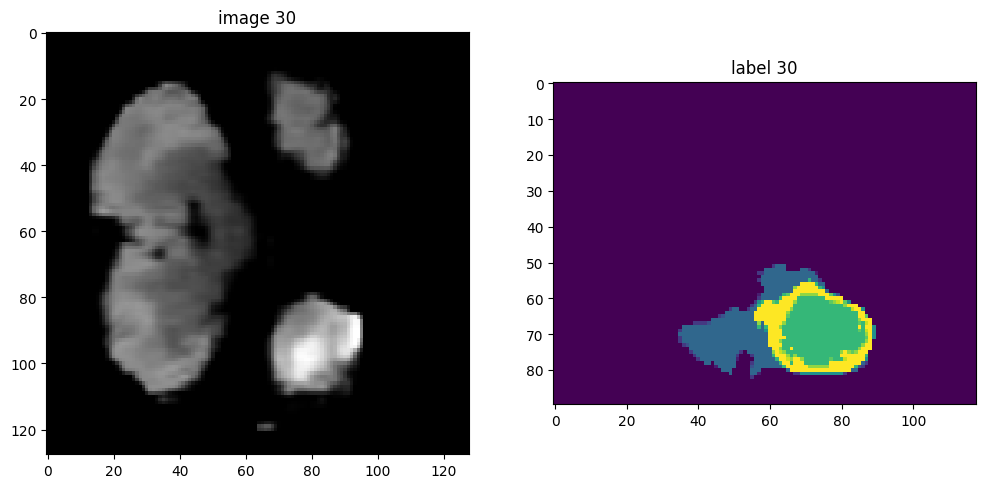

In [11]:
show_patient(patient,30)

In [11]:
class ConvertToMultiChannelBasedOnBratsClassesd(MapTransform):
    """
    Convert labels to multi channels based on brats classes:
    label 1 is the peritumoral edema
    label 2 is the GD-enhancing tumor
    label 3 is the necrotic and non-enhancing tumor core
    The possible classes are TC (Tumor core), WT (Whole tumor)
    and ET (Enhancing tumor).

    """

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            result = []
            # merge label 2 and label 3 to construct TC
            result.append(torch.logical_or(d[key] == 2, d[key] == 3))
            # merge labels 1, 2 and 3 to construct WT
            result.append(torch.logical_or(torch.logical_or(d[key] == 2, d[key] == 3), d[key] == 1))
            # label 2 is ET
            result.append(d[key] == 2)
            d[key] = torch.stack(result, axis=0).float()
        return d


In [12]:
def checking(data_dir, cache=False):
    set_determinism(seed=0)

    train_images = sorted(glob(os.path.join(data_dir, 'TrainVolumes', '*.nii.gz')))
    train_labels = sorted(glob(os.path.join(data_dir, 'TrainSegmentation', '*.nii.gz')))

    val_images = sorted(glob(os.path.join(data_dir, 'TestVolumes', '*.nii.gz')))
    val_labels = sorted(glob(os.path.join(data_dir, 'TestSegmentation', '*.nii.gz')))

    train_files = [{"image":image_name, "label":label_name} for image_name, label_name in zip(train_images, train_labels)]
    val_files = [{"image":image_name, "label":label_name} for image_name, label_name in zip(val_images, val_labels)]

    train_transforms = Compose(
        [
            # load 4 Nifti images and stack them together
            LoadImaged(keys=["image", "label"]),
            EnsureChannelFirstd(keys="image"),
            EnsureTyped(keys=["image", "label"]),
            ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
            Orientationd(keys=["image", "label"], axcodes="RAS"),
            Spacingd(
                keys=["image", "label"],
                pixdim=(1.0, 1.0, 1.0),
                mode=("bilinear", "nearest"),
            ),
            RandSpatialCropd(keys=["image", "label"], roi_size=[224, 224, 144], random_size=False),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
            RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
            NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
            RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
            RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
        ]
    )
    test_transforms = Compose(
        [
            LoadImaged(keys=["image", "label"]),
            EnsureChannelFirstd(keys="image"),
            EnsureTyped(keys=["image", "label"]),
            ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
            Orientationd(keys=["image", "label"], axcodes="RAS"),
            Spacingd(
                keys=["image", "label"],
                pixdim=(1.0, 1.0, 1.0),
                mode=("bilinear", "nearest"),
            ),
            NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
        ]
    )
    if cache:
        train_ds = CacheDataset(data=train_files, transform=train_transforms, cache_rate=1.0)
        train_loader = DataLoader(train_ds, batch_size=1)

        val_ds = CacheDataset(data=val_files, transform=test_transforms, cache_rate=1.0)
        val_loader = DataLoader(val_ds, batch_size=1)

        return train_loader, val_loader

    else:
        train_ds = Dataset(data = train_files, transform=train_transforms)
        train_loader = DataLoader(train_ds, batch_size=1)

        val_ds = Dataset(data = val_files, transform=test_transforms)
        val_loader = DataLoader(val_ds, batch_size=1)


        return train_loader, val_loader


In [30]:
patient1 = checking(data_dir)

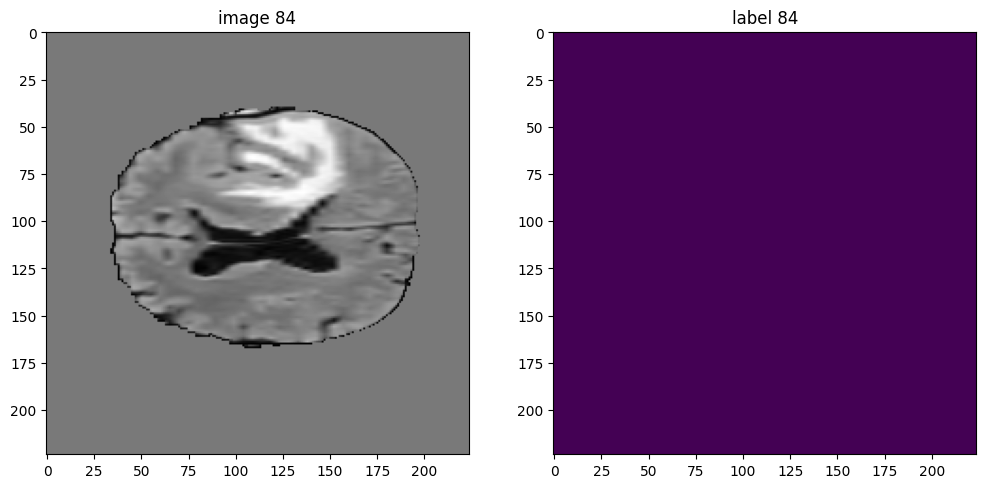

In [31]:
show_patient(patient1,84)